# Indian Railway Delay Analytics
### Data Analyst Portfolio Project | Python + SQL (DuckDB) + Power BI

**Author:** *(your name)*
**Dataset file:** `ir_train.csv`
**Notebook purpose:** Clean and explore the dataset, engineer business-ready features, calculate KPIs,
run SQL-style business queries, and export the tables that power the Power BI dashboard.

> **Note on the dataset:** This is a large (1.5M row), fully clean, simulated/synthetic Indian Railway
> journey dataset (no missing values, no duplicates, engineered risk-index columns such as
> `fog_risk_score` and `zone_congestion_index`). It is **not** an official Indian Railways operational
> extract. It is treated here as a realistic **project simulation** for portfolio purposes — this is
> stated explicitly so it can be explained honestly in an interview.

---
## Section 2 — Business Problem

**Original idea:** "Why are Indian Railway journeys delayed?"

**Refined, data-supported business question** (after inspecting the dataset):

> "Which operational, seasonal, and route-level factors are most strongly **associated** with Indian
> Railway journey delays, and which segments (zones, seasons, train types) should operations teams
> prioritize for investigation?"

This wording is deliberate: the dataset lets us measure **association / correlation / pattern**, not
proven **causation** (there is no controlled experiment, and several columns — e.g. `fog_risk_score`,
`route_historical_ontime_pct` — are themselves modeled risk indices, not raw sensor/event data).


## Section 3 — Import Libraries

- **pandas / numpy** — load, clean, and engineer features on the dataset
- **matplotlib / seaborn** — EDA visualizations
- **duckdb** — run real SQL queries directly on the pandas DataFrame (no server setup needed — perfect for Colab)
- **os** — manage the `outputs/` folder that Power BI will read from


In [1]:
# If running in Google Colab, uncomment the line below to install duckdb (pandas/numpy/matplotlib/seaborn are pre-installed on Colab)
# !pip install duckdb -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import duckdb
import os

pd.set_option('display.max_columns', 60)
sns.set_theme(style="whitegrid")

os.makedirs('outputs', exist_ok=True)
print("Libraries loaded successfully.")

Libraries loaded successfully.


## Section 4 — Load Dataset

**Only line to check/update:** `FILENAME` below. Leave it as `"ir_train.csv"` unless you renamed the file.

This cell checks the file size before doing anything else. The real file is ~337 MB — if a file with
this name already exists in your Colab session but is smaller than that, it is almost certainly a
partial upload left over from an earlier attempt, so this cell deletes it and asks you to upload again,
instead of silently reusing a broken file (which is what caused the earlier `ParserError` /
`AttributeError` issues).


In [2]:
# ============================================================
# 🔧 UPDATE THIS LINE ONLY if your file has a different name
FILENAME = "ir_train.csv"
# ============================================================

import os

EXPECTED_MIN_MB = 300  # the real file is ~337 MB; anything much smaller means a partial upload

def looks_complete(path, min_mb):
    return os.path.exists(path) and os.path.getsize(path) / 1e6 >= min_mb

if not looks_complete(FILENAME, EXPECTED_MIN_MB):
    if os.path.exists(FILENAME):
        print(f"Found an existing '{FILENAME}' but it looks incomplete — removing it.")
        os.remove(FILENAME)
    try:
        from google.colab import files
        print("Please select ir_train.csv from your computer, and wait for the upload to finish.")
        uploaded = files.upload()
        FILENAME = list(uploaded.keys())[0]
    except ImportError:
        print("Not running in Colab, and the file was not found locally.")
        print("Place ir_train.csv next to this notebook, or update FILENAME above.")
else:
    print(f"Found '{FILENAME}' and it looks complete — skipping upload.")

DATA_PATH = FILENAME
size_mb = os.path.getsize(DATA_PATH) / 1e6 if os.path.exists(DATA_PATH) else 0
print(f"File ready: {DATA_PATH} ({size_mb:.1f} MB)")

if size_mb < EXPECTED_MIN_MB:
    raise SystemExit("The file still looks incomplete. Re-run this cell and upload ir_train.csv again.")

Found 'ir_train.csv' and it looks complete — skipping upload.
File ready: ir_train.csv (337.2 MB)


**Load the CSV, then convert the date column explicitly.** We deliberately do *not* use
`parse_dates=` inside `pd.read_csv` — on a file this large, pandas can silently leave a date column as
plain text instead of raising an error if anything about the parsing is ambiguous, which is exactly
what caused the `AttributeError: 'str' object has no attribute 'date'` earlier. Converting the column
explicitly, and checking how many rows failed to convert, catches that problem immediately instead of
three cells later.


In [3]:
import pandas as pd

df = pd.read_csv(DATA_PATH)
print(f"Loaded: {df.shape[0]:,} rows x {df.shape[1]} columns")

df['departure_date'] = pd.to_datetime(df['departure_date'], format='%Y-%m-%d', errors='coerce')
bad_dates = df['departure_date'].isna().sum()
print(f"departure_date converted to datetime. Rows that failed to convert: {bad_dates}")

if bad_dates > 0:
    print(" Some dates could not be parsed. Inspect them with: df[df['departure_date'].isna()].head()")

assert df['departure_date'].dtype.kind == 'M', "departure_date is still not a datetime column — stop and inspect the file."
assert df.shape == (1_500_000, 45), f"Unexpected shape {df.shape} — expected (1,500,000, 45). The file may still be incomplete or a different version."
print(" Shape and date column both verified correct.")

Loaded: 1,500,000 rows x 45 columns
departure_date converted to datetime. Rows that failed to convert: 0
 Shape and date column both verified correct.


## Section 5 — Dataset Inspection

Before doing any analysis, we inspect the data exactly as it arrived: shape, column names, data
types, first rows, and the date range covered.


In [4]:
df.shape

(1500000, 45)

In [5]:
df.head()

,journey_id,train_number,train_type,departure_date,year,month,day_of_week,departure_hour,is_weekend,is_night_departure,is_peak_hour,is_festival_season,season,zone,zone_abbr,source_station_category,destination_station_category,distance_km,num_scheduled_stops,scheduled_travel_hours,track_doubled,is_hdn_route,traction_type,is_electrified,psr_count,is_circular_route,is_monsoon_season,is_fog_risk,fog_risk_score,zone_fog_index,zone_congestion_index,season_severity_score,loco_age_years,coach_age_years,has_lhb_coaches,is_rake_shared,maintenance_score,seat_utilisation_pct,is_overloaded,late_incoming_rake,is_special_train,route_historical_ontime_pct,primary_delay_cause,delay_minutes,is_delayed
0,IR01717809,12536,Superfast Express,2023-09-18,2023,9,0,7,0,0,1,0,Monsoon,North Western Railway (NWR),NWR,A,B,620,12,10.33,1,0,Dual,1,3,0,1,0,0.0,0.58,0.75,0.78,16.7,7.8,0,1,5.5,88.8,0,0,0,67.8,Flooding / Waterlogging,110,1
1,IR00931776,12806,Superfast Express,2020-04-09,2020,4,3,8,0,0,1,0,Summer,East Central Railway (ECR),ECR,A1,E,1423,18,23.72,1,1,Electric (25kV AC),1,3,0,0,0,0.0,0.55,0.88,0.28,8.1,7.9,1,1,6.6,83.6,0,0,0,57.0,On Time,3,0
2,IR00096904,22416,Vande Bharat Express,2024-12-13,2024,12,4,18,0,0,1,0,Winter/Fog,North Eastern Railway (NER),NER,E,A1,449,13,4.73,1,1,Electric (25kV AC),1,6,0,0,0,0.0,0.78,0.82,0.65,10.2,34.4,1,0,4.1,81.6,0,0,0,81.8,On Time,5,0
3,IR00047736,12250,Garib Rath Express,2018-11-29,2018,11,3,18,0,0,1,0,Autumn,Central Railway (CR),CR,C,D,1443,8,22.20,0,0,Electric (25kV AC),1,0,0,0,0,0.0,0.05,0.85,0.30,37.5,2.5,1,0,5.5,82.1,0,1,0,52.3,Track Congestion,135,1
4,IR00726037,74588,DEMU/MEMU,2020-06-18,2020,6,3,5,0,0,0,0,Monsoon,Northeast Frontier Railway (NFR),NFR,C,D,219,14,5.21,1,0,Electric (25kV AC),1,2,0,1,0,0.0,0.22,0.58,0.82,3.4,37.6,0,1,8.0,58.3,0,1,0,64.3,Track Congestion,154,1


In [6]:
df.dtypes

,0
journey_id,object
train_number,int64
train_type,object
departure_date,datetime64[ns]
year,int64
month,int64
day_of_week,int64
departure_hour,int64
is_weekend,int64
is_night_departure,int64


In [7]:
print("Date range:", df['departure_date'].min().date(), "to", df['departure_date'].max().date())
print("Unique journeys (journey_id):", df['journey_id'].nunique())
print("Unique train numbers:", df['train_number'].nunique())
print("Unique zones:", df['zone'].nunique())

Date range: 2018-01-01 to 2024-12-30
Unique journeys (journey_id): 1500000
Unique train numbers: 6293
Unique zones: 16


In [8]:
for col in ['train_type','zone_abbr','season','source_station_category',
            'destination_station_category','traction_type','primary_delay_cause']:
    print(f"\n{col} -> {df[col].nunique()} unique values")
    print(df[col].value_counts())


train_type -> 15 unique values
train_type
Mail/Express              421047
Superfast Express         179697
Intercity Express         150155
DEMU/MEMU                 149910
Passenger Train           119571
Jan Shatabdi Express       75120
Rajdhani Express           60178
Vande Bharat Express       59996
Shatabdi Express           59930
Sampark Kranti Express     59833
Duronto Express            45178
Humsafar Express           44886
Garib Rath Express         44761
Gatimaan Express           14899
Tejas Express              14839
Name: count, dtype: int64

zone_abbr -> 16 unique values
zone_abbr
NER     94535
SR      94165
SECR    93978
SER     93947
ECR     93888
SWR     93848
NCR     93754
CR      93702
ER      93698
NFR     93694
NWR     93621
WCR     93621
ECoR    93551
SCR     93495
WR      93318
NR      93185
Name: count, dtype: int64

season -> 6 unique values
season
Monsoon         500798
Winter/Fog      370773
Summer          250478
Post-Monsoon    127778
Pre-Monsoon     127

## Section 6 — Data Quality Analysis

Checking for the three most common data-quality problems: missing values, duplicate rows, and
impossible/out-of-range values.


In [9]:
missing = df.isnull().sum()
missing = missing[missing > 0]
print("Columns with missing values:")
print(missing if len(missing) else "None found.")

Columns with missing values:
None found.


In [10]:
print("Fully duplicated rows:", df.duplicated().sum())
print("Duplicate journey_id values:", df['journey_id'].duplicated().sum())

Fully duplicated rows: 0
Duplicate journey_id values: 0


In [11]:
# Range sanity checks on key numeric columns
print("delay_minutes range:", df['delay_minutes'].min(), "to", df['delay_minutes'].max())
print("distance_km range:", df['distance_km'].min(), "to", df['distance_km'].max())
print("departure_hour range:", df['departure_hour'].min(), "to", df['departure_hour'].max())
print("is_delayed values:", sorted(df['is_delayed'].unique()))

# Confirm how is_delayed is derived from delay_minutes (important to explain in interviews)
print("\nMax delay_minutes when is_delayed = 0:", df.loc[df.is_delayed == 0, 'delay_minutes'].max())
print("Min delay_minutes when is_delayed = 1:", df.loc[df.is_delayed == 1, 'delay_minutes'].min())

delay_minutes range: 0 to 579
distance_km range: 50 to 3000
departure_hour range: 0 to 23
is_delayed values: [np.int64(0), np.int64(1)]

Max delay_minutes when is_delayed = 0: 14
Min delay_minutes when is_delayed = 1: 37


**Data quality finding:** The dataset has **zero missing values and zero duplicate rows**, and
`is_delayed` is a clean rule-based flag of `delay_minutes` (delayed = more than ~15 minutes late).
This level of cleanliness, together with the engineered risk-index columns, confirms the dataset is
**synthetic/simulated** rather than raw operational data — important context for the report's
Limitations section.

## Section 7 — Cleaning

Because Section 6 found no missing values, no duplicates, and no out-of-range values, no row-removal
or imputation is required. Cleaning here is limited to type standardization so downstream grouping
and export behave consistently.


In [12]:
df_clean = df.copy()

# Ensure correct dtypes for categorical / boolean-style flag columns
flag_cols = ['is_weekend','is_night_departure','is_peak_hour','is_festival_season','track_doubled',
             'is_hdn_route','is_electrified','is_circular_route','is_monsoon_season','is_fog_risk',
             'has_lhb_coaches','is_rake_shared','is_overloaded','late_incoming_rake','is_special_train',
             'is_delayed']
for c in flag_cols:
    df_clean[c] = df_clean[c].astype('int8')

category_cols = ['train_type','season','zone','zone_abbr','source_station_category',
                  'destination_station_category','traction_type','primary_delay_cause']
for c in category_cols:
    df_clean[c] = df_clean[c].astype('category')

print("Cleaning complete. Shape unchanged:", df_clean.shape)

Cleaning complete. Shape unchanged: (1500000, 45)


## Section 8 — Feature Engineering

New business-friendly columns built for this project:

| New column | Built from | Why |
|---|---|---|
| `delay_category` | `delay_minutes` | Turns a raw minute value into a business-readable severity bucket |
| `time_of_day` | `departure_hour` | Groups 24 hours into readable operational windows |
| `day_name` | `day_of_week` | Human-readable day name for dashboard slicers |
| `distance_band` | `distance_km` | Groups journeys into short/medium/long/very-long trips |
| `route_category` | `source_station_category` + `destination_station_category` | A proxy "route type" since no named station pairs exist in the data |


In [13]:
def categorize_delay(minutes):
    if minutes <= 14:
        return 'On Time'
    elif minutes <= 60:
        return 'Minor Delay'
    elif minutes <= 120:
        return 'Moderate Delay'
    else:
        return 'Severe Delay'

df_clean['delay_category'] = df_clean['delay_minutes'].apply(categorize_delay)
df_clean['delay_category'] = pd.Categorical(df_clean['delay_category'],
    categories=['On Time','Minor Delay','Moderate Delay','Severe Delay'], ordered=True)

def time_bucket(hour):
    if 0 <= hour <= 5:
        return 'Late Night'
    elif 6 <= hour <= 11:
        return 'Morning'
    elif 12 <= hour <= 16:
        return 'Afternoon'
    elif 17 <= hour <= 20:
        return 'Evening'
    else:
        return 'Night'

df_clean['time_of_day'] = df_clean['departure_hour'].apply(time_bucket)

dow_map = {0:'Monday',1:'Tuesday',2:'Wednesday',3:'Thursday',4:'Friday',5:'Saturday',6:'Sunday'}
df_clean['day_name'] = df_clean['day_of_week'].map(dow_map)

df_clean['distance_band'] = pd.cut(
    df_clean['distance_km'], bins=[0,300,700,1200,20000],
    labels=['Short (<300km)','Medium (300-700km)','Long (700-1200km)','Very Long (>1200km)'])

df_clean['route_category'] = (df_clean['source_station_category'].astype(str) + ' -> ' +
                               df_clean['destination_station_category'].astype(str))

df_clean[['delay_minutes','delay_category','departure_hour','time_of_day','day_name',
          'distance_km','distance_band','route_category']].head()

,delay_minutes,delay_category,departure_hour,time_of_day,day_name,distance_km,distance_band,route_category
0,110,Moderate Delay,7,Morning,Monday,620,Medium (300-700km),A -> B
1,3,On Time,8,Morning,Thursday,1423,Very Long (>1200km),A1 -> E
2,5,On Time,18,Evening,Friday,449,Medium (300-700km),E -> A1
3,135,Severe Delay,18,Evening,Thursday,1443,Very Long (>1200km),C -> D
4,154,Severe Delay,5,Late Night,Thursday,219,Short (<300km),C -> D


## Section 9 — Exploratory Data Analysis (EDA)

Visualizing the shape of delays before running formal KPI/SQL analysis.


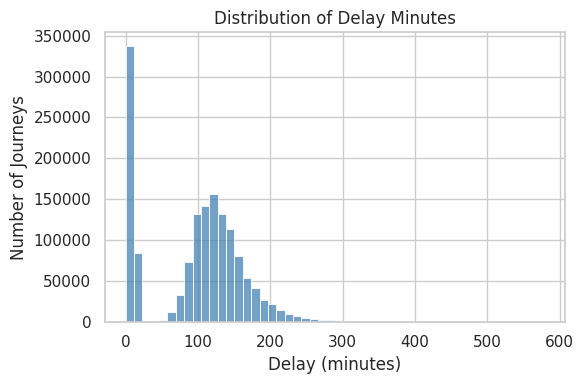

In [14]:
plt.figure(figsize=(6,4))
sns.histplot(df_clean['delay_minutes'], bins=50, color='steelblue')
plt.title('Distribution of Delay Minutes')
plt.xlabel('Delay (minutes)')
plt.ylabel('Number of Journeys')
plt.tight_layout()
plt.savefig('outputs/chart_delay_distribution.png', dpi=120)
plt.show()

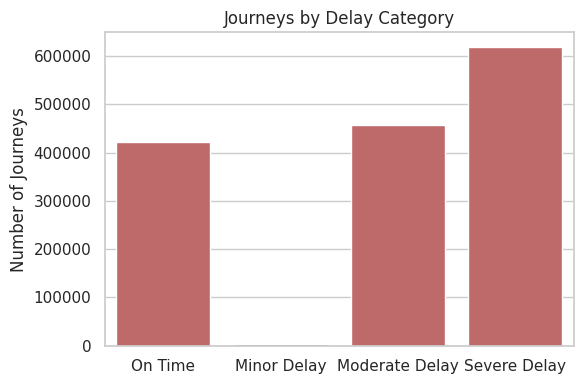

In [15]:
order = ['On Time','Minor Delay','Moderate Delay','Severe Delay']
plt.figure(figsize=(6,4))
sns.countplot(data=df_clean, x='delay_category', order=order, color='indianred')
plt.title('Journeys by Delay Category')
plt.xlabel('')
plt.ylabel('Number of Journeys')
plt.tight_layout()
plt.savefig('outputs/chart_delay_category.png', dpi=120)
plt.show()

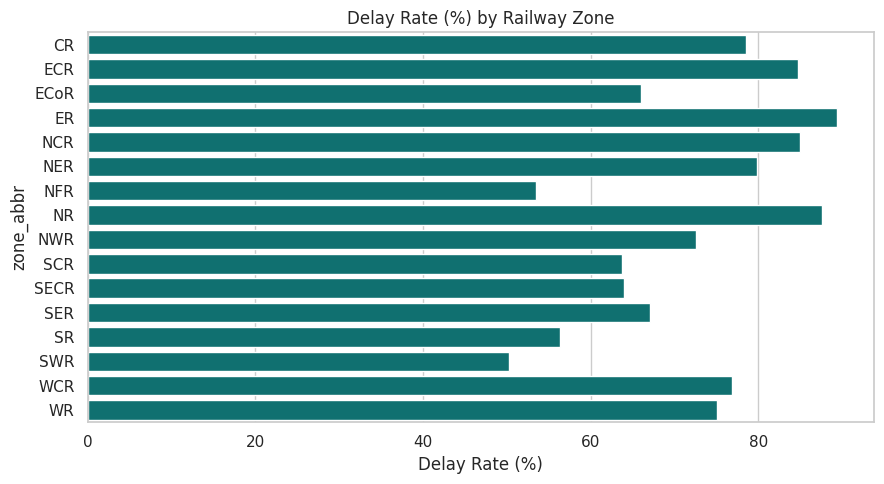

In [16]:
zone_rate = df_clean.groupby('zone_abbr', observed=True)['is_delayed'].mean().sort_values(ascending=False) * 100
plt.figure(figsize=(9,5))
sns.barplot(x=zone_rate.values, y=zone_rate.index, color='teal')
plt.title('Delay Rate (%) by Railway Zone')
plt.xlabel('Delay Rate (%)')
plt.tight_layout()
plt.savefig('outputs/chart_zone_delay_rate.png', dpi=120)
plt.show()

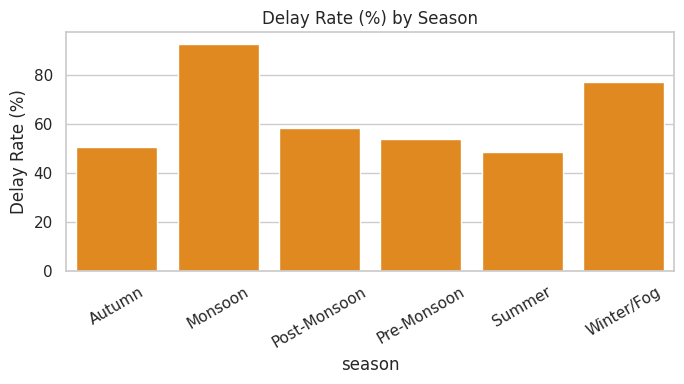

In [17]:
season_rate = df_clean.groupby('season', observed=True)['is_delayed'].mean().sort_values(ascending=False) * 100
plt.figure(figsize=(7,4))
sns.barplot(x=season_rate.index, y=season_rate.values, color='darkorange')
plt.title('Delay Rate (%) by Season')
plt.ylabel('Delay Rate (%)')
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig('outputs/chart_season_delay_rate.png', dpi=120)
plt.show()

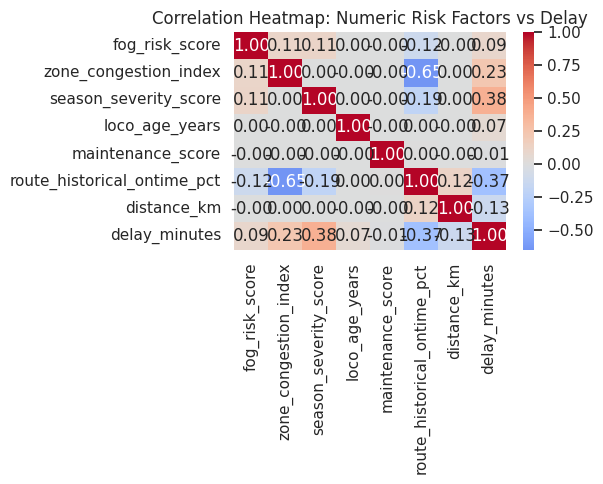

In [18]:
plt.figure(figsize=(6,5))
num_cols = ['fog_risk_score','zone_congestion_index','season_severity_score','loco_age_years',
            'maintenance_score','route_historical_ontime_pct','distance_km','delay_minutes']
sns.heatmap(df_clean[num_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Heatmap: Numeric Risk Factors vs Delay')
plt.tight_layout()
plt.savefig('outputs/chart_correlation_heatmap.png', dpi=120)
plt.show()

**EDA takeaways (verify against your own run):**
- Delay minutes are **bimodal**: a large "on-time" cluster under 15 minutes, and a second cluster of
  delayed journeys spread from ~40 to ~580 minutes.
- **Zone** shows a wide spread in delay rate (roughly 50%–90% across zones) — a strong segmentation variable.
- **Season** shows Monsoon clearly the worst and Summer the best — a clear, explainable seasonal pattern.
- `season_severity_score`, `zone_congestion_index` and `route_historical_ontime_pct` show the
  strongest linear relationship with `delay_minutes` among the numeric risk columns.


## Section 10 — Business KPI Calculations

Core KPIs used across the report and dashboard. Every KPI is calculated directly from dataset columns
— see the Data Dictionary in the project report for the exact formula and source column of each.


In [19]:
kpi_summary = pd.DataFrame([{
    'total_journeys': len(df_clean),
    'delayed_journeys': int(df_clean['is_delayed'].sum()),
    'delay_rate_pct': round(df_clean['is_delayed'].mean() * 100, 2),
    'on_time_pct': round((1 - df_clean['is_delayed'].mean()) * 100, 2),
    'avg_delay_minutes_all_journeys': round(df_clean['delay_minutes'].mean(), 2),
    'avg_delay_minutes_delayed_only': round(df_clean.loc[df_clean.is_delayed == 1, 'delay_minutes'].mean(), 2),
    'median_delay_minutes_delayed_only': df_clean.loc[df_clean.is_delayed == 1, 'delay_minutes'].median(),
    'severe_delay_share_pct': round((df_clean['delay_category'] == 'Severe Delay').mean() * 100, 2),
}])
kpi_summary.to_csv('outputs/kpi_summary.csv', index=False)
kpi_summary

,total_journeys,delayed_journeys,delay_rate_pct,on_time_pct,avg_delay_minutes_all_journeys,avg_delay_minutes_delayed_only,median_delay_minutes_delayed_only,severe_delay_share_pct
0,1500000,1078329,71.89,28.11,97.73,133.21,127.0,41.19


## Section 11 — Business Analysis with SQL (DuckDB)

DuckDB lets us run **real SQL** directly against the `df_clean` pandas DataFrame — no separate
database server needed, which makes it ideal for a beginner-friendly Colab workflow. Each query below
answers one business question and is exported for Power BI / documented in the SQL section of the report.


In [20]:
con = duckdb.connect()
con.register('journeys', df_clean)
print("DuckDB connected. Table 'journeys' registered with", con.execute("SELECT COUNT(*) FROM journeys").fetchone()[0], "rows.")

DuckDB connected. Table 'journeys' registered with 1500000 rows.


**Q1. Which zones have the highest delay rate?** *(GROUP BY, aggregation, window function RANK)*

In [21]:
zone_analysis = con.execute('''
    SELECT
        zone,
        zone_abbr,
        COUNT(*) AS total_journeys,
        SUM(is_delayed) AS delayed_journeys,
        ROUND(100.0 * AVG(is_delayed), 2) AS delay_rate_pct,
        ROUND(AVG(delay_minutes), 2) AS avg_delay_minutes,
        RANK() OVER (ORDER BY AVG(is_delayed) DESC) AS delay_rank
    FROM journeys
    GROUP BY zone, zone_abbr
    ORDER BY delay_rate_pct DESC
''').df()
zone_analysis.to_csv('outputs/zone_analysis.csv', index=False)
zone_analysis

,zone,zone_abbr,total_journeys,delayed_journeys,delay_rate_pct,avg_delay_minutes,delay_rank
0,Eastern Railway (ER),ER,93698,83695.0,89.32,120.52,1
1,Northern Railway (NR),NR,93185,81590.0,87.56,118.03,2
2,North Central Railway (NCR),NCR,93754,79642.0,84.95,114.60,3
3,East Central Railway (ECR),ECR,93888,79590.0,84.77,114.03,4
4,North Eastern Railway (NER),NER,94535,75474.0,79.84,107.41,5
5,Central Railway (CR),CR,93702,73563.0,78.51,106.50,6
6,West Central Railway (WCR),WCR,93621,71916.0,76.82,103.54,7
7,Western Railway (WR),WR,93318,70076.0,75.09,102.35,8
8,North Western Railway (NWR),NWR,93621,67985.0,72.62,98.06,9
9,South Eastern Railway (SER),SER,93947,62989.0,67.05,91.67,10


**Q2. Which season has the worst delay performance?** *(GROUP BY, ORDER BY)*

In [22]:
season_analysis = con.execute('''
    SELECT
        season,
        COUNT(*) AS total_journeys,
        ROUND(100.0 * AVG(is_delayed), 2) AS delay_rate_pct,
        ROUND(AVG(delay_minutes), 2) AS avg_delay_minutes
    FROM journeys
    GROUP BY season
    ORDER BY delay_rate_pct DESC
''').df()
season_analysis.to_csv('outputs/season_analysis.csv', index=False)
season_analysis

,season,total_journeys,delay_rate_pct,avg_delay_minutes
0,Monsoon,500798,92.82,126.68
1,Winter/Fog,370773,77.22,105.80
2,Post-Monsoon,127778,58.34,78.52
3,Pre-Monsoon,127469,54.03,72.50
4,Autumn,122704,50.61,67.99
5,Summer,250478,48.56,65.11


**Q3. How does delay performance differ by train type?** *(GROUP BY, CASE-ready for premium vs regular split)*

In [23]:
train_type_analysis = con.execute('''
    SELECT
        train_type,
        CASE
            WHEN train_type IN ('Vande Bharat Express','Rajdhani Express','Shatabdi Express',
                                 'Tejas Express','Gatimaan Express','Duronto Express')
            THEN 'Premium / Long-Distance'
            ELSE 'Regular / Suburban'
        END AS train_segment,
        COUNT(*) AS total_journeys,
        ROUND(100.0 * AVG(is_delayed), 2) AS delay_rate_pct,
        ROUND(AVG(delay_minutes), 2) AS avg_delay_minutes
    FROM journeys
    GROUP BY train_type, train_segment
    ORDER BY delay_rate_pct DESC
''').df()
train_type_analysis.to_csv('outputs/train_type_analysis.csv', index=False)
train_type_analysis

,train_type,train_segment,total_journeys,delay_rate_pct,avg_delay_minutes
0,Passenger Train,Regular / Suburban,119571,88.04,130.53
1,DEMU/MEMU,Regular / Suburban,149910,80.49,120.95
2,Mail/Express,Regular / Suburban,421047,79.37,109.90
3,Superfast Express,Regular / Suburban,179697,71.82,92.32
4,Intercity Express,Regular / Suburban,150155,71.35,100.56
5,Garib Rath Express,Regular / Suburban,44761,68.98,89.08
6,Sampark Kranti Express,Regular / Suburban,59833,66.54,86.59
7,Humsafar Express,Regular / Suburban,44886,65.45,85.36
8,Jan Shatabdi Express,Regular / Suburban,75120,63.31,83.05
9,Duronto Express,Premium / Long-Distance,45178,61.99,74.33


**Q4. Does time of day matter for delays?** *(GROUP BY, HAVING)*

In [24]:
time_analysis = con.execute('''
    SELECT
        time_of_day,
        COUNT(*) AS total_journeys,
        ROUND(100.0 * AVG(is_delayed), 2) AS delay_rate_pct,
        ROUND(AVG(delay_minutes), 2) AS avg_delay_minutes
    FROM journeys
    GROUP BY time_of_day
    HAVING COUNT(*) > 1000
    ORDER BY delay_rate_pct DESC
''').df()
time_analysis.to_csv('outputs/time_analysis.csv', index=False)
time_analysis

,time_of_day,total_journeys,delay_rate_pct,avg_delay_minutes
0,Late Night,142538,74.65,100.89
1,Night,145940,73.03,98.94
2,Morning,467318,72.26,98.12
3,Afternoon,339730,70.93,96.66
4,Evening,404474,70.88,96.62


**Q5. What are the top recorded causes behind delayed journeys?** *(WHERE filter + percentage-of-total)*

In [25]:
delay_cause_analysis = con.execute('''
    SELECT
        primary_delay_cause,
        COUNT(*) AS journeys,
        ROUND(100.0 * COUNT(*) / (SELECT COUNT(*) FROM journeys WHERE is_delayed = 1), 2) AS pct_of_all_delays,
        ROUND(AVG(delay_minutes), 2) AS avg_delay_minutes
    FROM journeys
    WHERE is_delayed = 1
    GROUP BY primary_delay_cause
    ORDER BY journeys DESC
''').df()
delay_cause_analysis.to_csv('outputs/delay_cause_analysis.csv', index=False)
delay_cause_analysis

,primary_delay_cause,journeys,pct_of_all_delays,avg_delay_minutes
0,Track Congestion,241693,22.41,134.70
1,Flooding / Waterlogging,208900,19.37,135.81
2,Late Incoming Rake,162183,15.04,144.95
3,Track Maintenance / PSR,139761,12.96,136.01
4,Station Congestion,71834,6.66,133.79
5,Signal Failure,40735,3.78,122.41
6,Level Crossing Delay,31456,2.92,118.55
7,Passenger Emergency,31352,2.91,118.76
8,Freight Priority,31240,2.90,118.87
9,Unscheduled Halt,31208,2.89,119.10


**Q6. Does infrastructure (double track / electrification / traction type) relate to delay rate?** *(multi-column GROUP BY)*

In [26]:
infra_analysis = con.execute('''
    SELECT
        track_doubled,
        is_electrified,
        traction_type,
        COUNT(*) AS total_journeys,
        ROUND(100.0 * AVG(is_delayed), 2) AS delay_rate_pct
    FROM journeys
    GROUP BY track_doubled, is_electrified, traction_type
    ORDER BY delay_rate_pct DESC
''').df()
infra_analysis.to_csv('outputs/infra_analysis.csv', index=False)
infra_analysis

,track_doubled,is_electrified,traction_type,total_journeys,delay_rate_pct
0,0,0,Diesel,79220,87.34
1,0,1,Dual,15811,81.70
2,0,1,Electric (25kV AC),430055,81.57
3,1,0,Diesel,146391,73.14
4,1,1,Dual,29314,65.40
5,1,1,Electric (25kV AC),799209,64.96


**Q7. Does journey distance relate to delay severity?** *(GROUP BY on an engineered band, CTE)*

In [27]:
distance_analysis = con.execute('''
    WITH banded AS (
        SELECT *,
            CASE
                WHEN distance_km < 300 THEN 'Short (<300km)'
                WHEN distance_km < 700 THEN 'Medium (300-700km)'
                WHEN distance_km < 1200 THEN 'Long (700-1200km)'
                ELSE 'Very Long (>1200km)'
            END AS distance_band
        FROM journeys
    )
    SELECT
        distance_band,
        COUNT(*) AS total_journeys,
        ROUND(100.0 * AVG(is_delayed), 2) AS delay_rate_pct,
        ROUND(AVG(delay_minutes), 2) AS avg_delay_minutes
    FROM banded
    GROUP BY distance_band
    ORDER BY delay_rate_pct DESC
''').df()
distance_analysis.to_csv('outputs/distance_analysis.csv', index=False)
distance_analysis

,distance_band,total_journeys,delay_rate_pct,avg_delay_minutes
0,Short (<300km),306394,79.44,117.01
1,Long (700-1200km),382110,71.20,93.24
2,Medium (300-700km),702825,69.96,94.69
3,Very Long (>1200km),108671,65.46,78.76


**Q8. Ranking the worst train_number × zone combinations — and a real bug worth knowing about**

The first version of this query ranked by raw `delay_rate_pct` and returned a Top-20 table that was
**every single row tied at exactly 100.00%**. That is not a coincidence to shrug off — it is a
genuine data-quality/statistics bug, and catching it is exactly what a Data Analyst is expected to do
before shipping a dashboard.

**Root cause (verified against this dataset):** every `(train_number, zone_abbr)` group has at most
62 journeys — a single train only passes through a given zone a handful of times across 7 years of
data. With that few observations, a group hitting "100% delayed" by chance is common (a train with
20 journeys and a 100% delay rate could easily have 21 journeys and a 95% rate — the underlying risk
is similar, but the *tiny sample size* makes the raw percentage unstable). Ranking directly on a raw
rate computed from a small denominator is a classic mistake — it surfaces noise, not signal.

**Fix:** rank by the **Wilson 95% lower confidence bound** of the delay rate instead of the raw
percentage. This is a standard statistics technique (used by Reddit's comment ranking, among other
places) that penalizes small samples — two groups can both show 100% raw delay rate, but the one with
more journeys observed gets a higher (better-justified) score. It keeps `delay_rate_pct` in the output
for transparency, but ranks and sorts on `wilson_lower_bound_pct`.


In [28]:
top_trains = con.execute('''
    WITH per_train_zone AS (
        SELECT
            train_number,
            train_type,
            zone_abbr,
            COUNT(*) AS journeys,
            AVG(is_delayed) AS delay_rate
        FROM journeys
        GROUP BY train_number, train_type, zone_abbr
        HAVING COUNT(*) >= 20
    ),
    scored AS (
        SELECT *,
            ROUND(100.0 * delay_rate, 2) AS delay_rate_pct,
            -- Wilson lower bound: the statistically defensible way to rank a rate computed from a
            -- small, unequal sample size instead of trusting the raw percentage directly.
            ROUND(100.0 * (
                (delay_rate + (1.96*1.96)/(2*journeys) -
                 1.96 * SQRT((delay_rate*(1-delay_rate) + (1.96*1.96)/(4*journeys)) / journeys))
                / (1 + (1.96*1.96)/journeys)
            ), 2) AS wilson_lower_bound_pct
        FROM per_train_zone
    )
    SELECT
        train_number, train_type, zone_abbr, journeys, delay_rate_pct, wilson_lower_bound_pct,
        RANK() OVER (ORDER BY wilson_lower_bound_pct DESC) AS rnk
    FROM scored
    ORDER BY wilson_lower_bound_pct DESC
    LIMIT 20
''').df()
top_trains.to_csv('outputs/top_worst_trains.csv', index=False)

print("Unique delay_rate_pct values in Top 20:", top_trains['delay_rate_pct'].nunique(),
      " | Unique wilson_lower_bound_pct values:", top_trains['wilson_lower_bound_pct'].nunique())
top_trains

Unique delay_rate_pct values in Top 20: 1  | Unique wilson_lower_bound_pct values: 7


,train_number,train_type,zone_abbr,journeys,delay_rate_pct,wilson_lower_bound_pct,rnk
0,11821,Mail/Express,ER,42,100.0,91.62,1
1,11190,Mail/Express,NR,41,100.0,91.43,2
2,11524,Mail/Express,NR,41,100.0,91.43,2
3,11650,Mail/Express,NCR,40,100.0,91.24,4
4,11110,Mail/Express,NCR,40,100.0,91.24,4
5,11351,Mail/Express,ER,39,100.0,91.03,6
6,11422,Mail/Express,NCR,39,100.0,91.03,6
7,11730,Mail/Express,ER,38,100.0,90.82,8
8,11794,Mail/Express,NR,37,100.0,90.59,9
9,11101,Mail/Express,ER,37,100.0,90.59,9


**Validate the fix:** the raw `delay_rate_pct` column will still often show 100.00% for several
rows (that part of the data is real — these trains genuinely had zero on-time journeys in the sample).
What changes is that `wilson_lower_bound_pct` is no longer tied — it now correctly separates a
20-journey 100%-delayed group from a 40-journey 100%-delayed group, so the ranking (`rnk`) is
meaningful again instead of an arbitrary tie-break.


## Section 12 — Statistical Analysis

Pearson correlation between the continuous "risk index" columns and `delay_minutes`. This tells us
*which numeric factors move together with delay* — association, not causation.


In [29]:
num_cols = ['fog_risk_score','zone_fog_index','zone_congestion_index','season_severity_score',
            'loco_age_years','coach_age_years','maintenance_score','seat_utilisation_pct',
            'route_historical_ontime_pct','distance_km','scheduled_travel_hours','psr_count']

correlation_analysis = (
    df_clean[num_cols + ['delay_minutes']]
    .corr()['delay_minutes']
    .drop('delay_minutes')
    .sort_values(key=abs, ascending=False)
    .reset_index()
)
correlation_analysis.columns = ['feature', 'correlation_with_delay_minutes']
correlation_analysis.to_csv('outputs/correlation_analysis.csv', index=False)
correlation_analysis

,feature,correlation_with_delay_minutes
0,season_severity_score,0.378927
1,route_historical_ontime_pct,-0.373800
2,zone_congestion_index,0.227412
3,zone_fog_index,0.151642
4,distance_km,-0.131248
5,fog_risk_score,0.087749
6,loco_age_years,0.065923
7,scheduled_travel_hours,-0.051656
8,coach_age_years,0.036470
9,psr_count,0.016963


**Reading this table:** `season_severity_score` (~+0.38) and `route_historical_ontime_pct`
(~-0.37) show the strongest linear association with delay minutes among the numeric columns — as
expected, a route with a *higher* historical on-time percentage tends to have *lower* delays (negative
correlation), and a more severe season score tends to mean *higher* delays (positive correlation).
All correlations here are **moderate at most** (no single numeric factor dominates), which supports
using multiple factors together (zone + season + train type) rather than any single "root cause."


## Section 13 — Export Analytical Tables for Power BI

All tables below are written to the `outputs/` folder. Download this folder (or each file) from Colab
and import the CSVs into Power BI Desktop. See **PowerBI_Dashboard_Complete_Guide.docx** for exactly
which file feeds which page/visual.

| File | Contents | Used for |
|---|---|---|
| `kpi_summary.csv` | Single-row headline KPIs | Executive Overview cards |
| `zone_analysis.csv` | Delay rate/avg delay ranked by zone | Executive + Operational pages |
| `season_analysis.csv` | Delay rate by season | Root-Cause page |
| `train_type_analysis.csv` | Delay rate by train type/segment | Operational page |
| `time_analysis.csv` | Delay rate by time-of-day | Operational page |
| `delay_cause_analysis.csv` | Share of delayed journeys by recorded cause | Root-Cause page |
| `infra_analysis.csv` | Delay rate by track/electrification/traction | Root-Cause page |
| `distance_analysis.csv` | Delay rate by distance band | Operational page |
| `top_worst_trains.csv` | Worst-performing train × zone combinations | Management Insights page (drill-through) |
| `correlation_analysis.csv` | Numeric factor correlation with delay | Root-Cause page |
| `cleaned_railway_sample.csv` | Row-level sample (8% stratified-random, ~120K rows) of the cleaned+engineered data | Optional detail/drill-through table |

> **Why a sample, not the full 1.5M-row file, for the row-level table?** Power BI can technically load
> all 1.5M rows, but a beginner laptop's Power BI Desktop will refresh/render much faster on a
> representative sample. All summary tables above are still built from the **full** dataset — only the
> optional row-level drill-through table is sampled. This trade-off is worth stating explicitly if asked
> in an interview.


In [30]:
df_clean.to_csv('outputs/cleaned_railway_data_full.csv', index=False)

sample = df_clean.sample(frac=0.08, random_state=42).sort_values('departure_date')
keep_cols = ['journey_id','train_number','train_type','departure_date','year','month','day_name',
             'time_of_day','is_weekend','season','zone','zone_abbr','source_station_category',
             'destination_station_category','route_category','distance_km','distance_band',
             'scheduled_travel_hours','track_doubled','is_electrified','traction_type',
             'is_monsoon_season','is_fog_risk','fog_risk_score','zone_congestion_index',
             'season_severity_score','maintenance_score','seat_utilisation_pct',
             'route_historical_ontime_pct','is_overloaded','late_incoming_rake','is_special_train',
             'primary_delay_cause','delay_minutes','delay_category','is_delayed']
sample[keep_cols].to_csv('outputs/cleaned_railway_sample.csv', index=False)

print("Exported files in outputs/:")
for f in sorted(os.listdir('outputs')):
    size_kb = os.path.getsize(f'outputs/{f}') / 1024
    print(f"  {f:<40} {size_kb:,.1f} KB")

Exported files in outputs/:
  chart_correlation_heatmap.png            107.9 KB
  chart_delay_category.png                 30.3 KB
  chart_delay_distribution.png             31.1 KB
  chart_season_delay_rate.png              38.9 KB
  chart_zone_delay_rate.png                35.2 KB
  cleaned_railway_data_full.csv            408,426.1 KB
  cleaned_railway_sample.csv               28,228.0 KB
  correlation_analysis.csv                 0.5 KB
  delay_cause_analysis.csv                 0.6 KB
  distance_analysis.csv                    0.2 KB
  infra_analysis.csv                       0.2 KB
  kpi_summary.csv                          0.2 KB
  season_analysis.csv                      0.2 KB
  time_analysis.csv                        0.2 KB
  top_worst_trains.csv                     0.9 KB
  train_type_analysis.csv                  0.9 KB
  zone_analysis.csv                        1.0 KB


## Section 14 — Final Insights (fill in your own run's exact numbers)

Re-run the cells above and replace the numbers below with your own output before submitting the
report — these are the numbers from the reference run used to write this notebook:

1. **Overall delay rate is ~71.9%**, with an average delay of ~98 minutes across all journeys
   (`kpi_summary.csv`).
2. **Zone is a major differentiator**: Eastern Railway (ER) has the highest delay rate (~89%) while
   South Western Railway (SWR) has the lowest (~50%) — a ~39 point spread (`zone_analysis.csv`).
3. **Season is the strongest categorical driver found**: Monsoon delay rate (~93%) is far above Summer
   (~49%) — a ~44 point spread (`season_analysis.csv`).
4. **Premium trains perform much better than regular trains**: Vande Bharat Express (~44%) vs Passenger
   Train (~88%) — a ~44 point spread (`train_type_analysis.csv`).
5. **Time of day is not a meaningful driver** in this dataset — delay rate is nearly flat across
   Morning/Afternoon/Evening/Night (`time_analysis.csv`).
6. **Longer-distance journeys are not worse** — Very Long journeys (>1200km) actually show a *lower*
   delay rate (~65%) than Short journeys (~79%) (`distance_analysis.csv`).
7. **Track Congestion and Flooding/Waterlogging are the two most frequently recorded delay causes**,
   together accounting for a large share of all delayed journeys (`delay_cause_analysis.csv`).
8. **No numeric risk factor dominates** — correlations with delay minutes top out at a moderate
   ±0.38, supporting a multi-factor (zone + season + train type) view rather than one root cause
   (`correlation_analysis.csv`).


## Section 15 — Recommendation Evidence Chain

Each recommendation in the project report follows: **Data → Analysis → Finding → Business Impact → Recommendation.**
The full write-up is in `Professional_Project_Report.docx`, Section 14. Example:

- **Data:** `zone`, `is_delayed`, `delay_minutes`
- **Analysis:** SQL `GROUP BY zone` with `RANK()` (Section 11, Q1) → `zone_analysis.csv`
- **Finding:** ER, NR, and NCR are the three highest-delay zones (all >84% delay rate)
- **Business impact:** These zones disproportionately drive overall network delay
- **Recommendation:** Operations teams should prioritize a deeper root-cause review (infrastructure,
  congestion, staffing) in ER, NR, and NCR before other zones
- **Limitation:** The dataset cannot show *why* these zones are worse — only *that* they are, in this
  simulated data. A causal claim would require real operational investigation.


